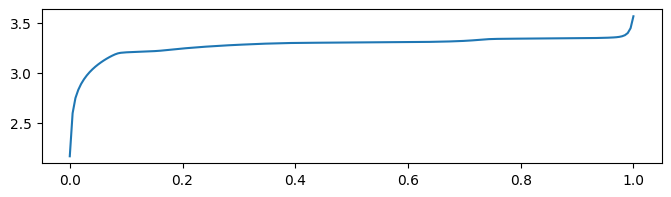

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from ecm_fitting.cached_data.ocv import get_ocv, get_soc_from_ocv
from ecm_fitting.cached_data.dummy_hppc import dummy_data

# The LFP/Gr model number
cell_code = "APR18650M1B"

def ocv_fn(soc):
    return float(get_ocv(cell_code=cell_code)(soc * 100))

def soc_fn(ocv):
    return float(get_soc_from_ocv(cell_code=cell_code)(ocv)) / 100


socs = np.linspace(0, 1, num=200)
plt.figure(figsize=(8,2))
plt.plot(socs, [ocv_fn(s) for s in socs])
plt.show()

In [ ]:
ocv_fn(0)

2.1681453613281247

: 

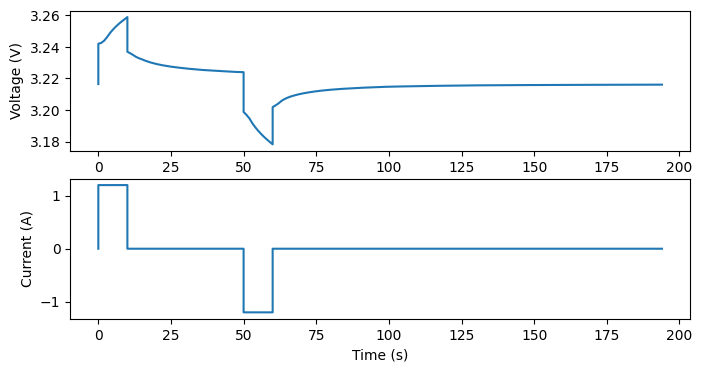

In [2]:
# Example of HPPC data
data = dummy_data()
fig, axes = plt.subplots(figsize=(8,4), nrows=2)
axes[0].plot(data["time"], data["voltage"])
axes[0].set_ylabel("Voltage (V)")
axes[1].plot(data["time"], data["current"])
axes[1].set_ylabel("Current (A)")
axes[1].set_xlabel("Time (s)")
plt.show()

In [3]:
from ecm_fitting.data.device import Battery
from ecm_fitting.data.registry import get_battery_type
from ecm_fitting.data.segment import DataSegment

# Can create a "Battery" instance
# The idea is that each "Battery" instance represents a physically unique battery (ie each tested cell)
battery = Battery(
    battery_type=get_battery_type(cell_code),
    cell_id="cell1",
)

# Data needs to be converted to "DataSegment" instances
# Think of a DataSegment as each HPPC pulse sequence
# (anything you want to be treated a single instance of data to fit to)
# We will also need to know (or guess) the SOC at the start of the data segment
# If we assume the pulses is starting from equilibrium (ie OCV), we can estimated SOC with:
soc_init = soc_fn(ocv=data["voltage"][0])
print(f"Initial SOC: {soc_init*100:.03f}%")

ds = DataSegment(
    time=data["time"],
    voltage=data["voltage"],
    current=data["current"],
    soc_init=soc_init, 
    # You can ignore the below (it will be good as is for the LFP/Gr cells)
    ocv_func=ocv_fn,
    capacity_ah=battery.battery_type.nominal_capacity_ah,
    battery=battery,
)

Initial SOC: 15.178%


In [13]:
from ecm_fitting.data.registry import get_init_bounds_for_device
from ecm_fitting.ecm.common import first_order_ecm, second_order_ecm
from ecm_fitting.ecm.simulator import ECMSimulator
from ecm_fitting.fitting.local_fitter import LocalFitter

# Select a 1st-order model (can also use `second_order_ecm`)
# Intiallized with an inital guess of all ECM parameters
# - these initial guesses are pre-defined for the LFP 18650 cells
ecm = first_order_ecm(**get_init_bounds_for_device(cell_code))

# We then defined a fitter instance for our model type, and call `.fit` on the DataSegment
fitter = LocalFitter(model=ecm)
fit_result = fitter.fit(ds)

print("Parameter values:")
for k,v in fit_result.parameters.to_dict().items():
    print(f"- {k}: {v:.03f}")

Parameter values:
- R0: 0.021
- R1: 0.048
- Tau1: 33.259


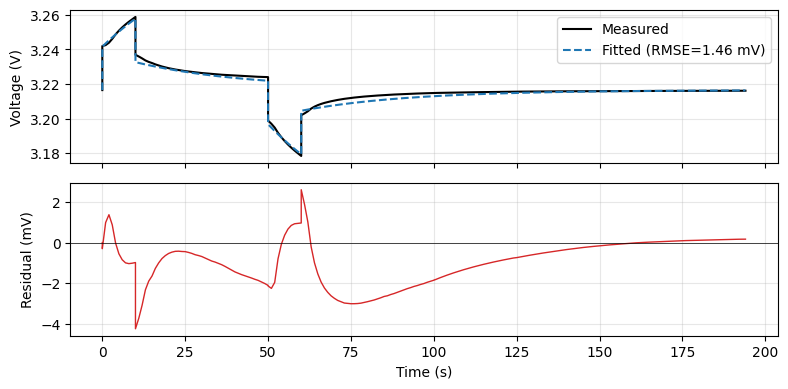

In [14]:
# We can now compare our models simulated voltage for the same current data
sim = ECMSimulator(model=ecm)
sim_result = sim.simulate(
    segment=ds,
    parameters=fit_result.parameters,
)

# Plot simulated vs measured voltage & the residual errors
rmse_mv = 1000 * np.sqrt(np.mean(sim_result.residuals**2))
fig, axes = plt.subplots(figsize=(8, 4), nrows=2, sharex=True)
axes[0].plot(ds.time, ds.voltage, "k", label="Measured")
axes[0].plot(ds.time, sim_result.v_sim, "C0--", label=f"Fitted (RMSE={rmse_mv:.2f} mV)")
axes[0].set_ylabel("Voltage (V)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ds.time, sim_result.residuals * 1000, "C3", lw=1)
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_ylabel("Residual (mV)")
axes[1].set_xlabel("Time (s)")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()